# 46 — AHoJ Holo vs Experimental: DrugCLIP score comparison (pooled, cross-dataset deduplicated)

**Companion to [37b_afdb_vs_experimental_scores_6A_pooled.ipynb](37b_afdb_vs_experimental_scores_6A_pooled.ipynb)
and [45_ahoj_apo_vs_experimental_scores_pooled.ipynb](45_ahoj_apo_vs_experimental_scores_pooled.ipynb).** Same population-handling approach as 37b — pooled,
cross-dataset-deduplicated corpus, square plots, explicit UniProt-collision accounting — applied
here to **AHoJ-DB holo counterparts** instead of AlphaFold models.

AHoJ-DB holo counterparts are *other* experimentally determined structures of the same protein that also have **some** ligand bound — not necessarily the same ligand, crystal form, or space group as the source structure nb14/37b score against. Comparing the bound ligand's DrugCLIP score against its own experimental pocket vs. against these other holo conformations isolates **crystal-form / deposition variation at fixed ligand-occupancy status**: if scores collapse here too — despite both sides being genuinely liganded — the drop isn't specific to the apo/holo transition, it reflects ordinary structural noise across independently solved structures of the same protein. That sets a lower bound on how much of 37b's AFDB score drop should be attributed to AlphaFold's own inaccuracy vs. simply "any other structure of this protein, even another crystal form, gives a somewhat different score" (see nb42's condition table: holo = "crystal-form variation").

**Fourth change relative to 37b, specific to AHoJ:** each source (bound) pocket has **zero to
hundreds** of AHoJ holo counterparts (exact median/max printed in §1b), unlike AFDB's
exactly-one static model per protein. Naively scoring every counterpart as its
own row would let a handful of heavily-redeposited proteins (e.g. HIV protease, lysozyme) dominate
every downstream statistic purely by counterpart count. §1b **pools every source pocket down to one
row**: the ligand–holo score is **mean-pooled** across all QC-passing holo counterparts of
that pocket (mean-pooling scores is exactly equivalent to scoring against the mean-pooled counterpart
embedding, by linearity of the dot product — the same convention nb42/nb43 use for their multi-counterpart
conditions), and each RMSD metric is the **median** across counterparts (median rather than mean since
RMSD is not linear and a handful of poor AHoJ hits can otherwise dominate the average).

**QC filter:** `mapping_rate == 1.0` (every source-pocket residue successfully mapped onto the target)
and `atomset_match == True` (identical heavy-atom composition) — the same "same residues, same atoms"
standard 37b applies via `pocket_identity`/`atomset_match` for AFDB.

**Inputs:**
- `RESULTS/ahoj_pockets_<ds>/ahoj_scores.tsv` — per-(source, target) DrugCLIP scores + RMSD (already computed, nb41)
- `RESULTS/ahoj_pockets_<ds>/pocket_manifest.tsv` — `atomset_match` QC column (not cached in every `ahoj_scores.tsv`, re-merged here)
- `NATURAL_LIGANDS/RESULTS/mols/bound_<ds>_manifest.tsv` — `pdb_id`, `lig_resname` for cross-dataset dedup
- `RESULTS/afdb_pockets_6A/afdb_pockets_manifest_qc.tsv` — `uniprot_acc` lookup (same SIFTS mapping used for the AFDB notebooks; source pockets are the same universe)

In [1]:
from __future__ import annotations
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import stats

NL   = Path.cwd().parent / 'DATA' / 'natural_ligands' / 'RESULTS'
PROJ = Path.cwd().parent / 'DATA' / 'drugclip'
OUT_DIR = PROJ / 'RESULTS/ahoj_pooled'
OUT_DIR.mkdir(exist_ok=True)

DATASETS = ['coach420', 'holo4k', 'pdbbind2020', 'scpdb']
DS_COLORS = {
    'coach420':    '#4C72B0',
    'holo4k':      '#DD8452',
    'pdbbind2020': '#55A868',
    'scpdb':       '#C44E52',
}
# Condition colours shared with 42_drugclip_benchmark.ipynb's COLOURS dict (and
# with 37b_afdb_vs_experimental_scores_6A_pooled.ipynb), so "experimental" /
# "apo" / "holo" mean the same colour in every notebook that plots them.
SOURCE_C = '#2CA02C'   # 'bound' in nb42
TARGET_C = '#FF7F0E'   # 'apo' -> #1F77B4, 'holo' -> #FF7F0E in nb42
PP_C     = '#17BECF'   # 'ccd' in nb42 — used for the pocket-pocket similarity metric,
                        # which has no condition of its own in nb42's scheme

TARGET = 'holo'          # 'apo' or 'holo'
SCORE_COL = 'score_holo'
N_COL = 'n_holo'

# Same key + priority as NATURAL_LIGANDS/scripts/combined_deleakage_analysis.py
# (dedup_cross_dataset / DATASET_PRIORITY) — used identically in 37b.
DEDUP_PRIORITY = ['coach420', 'scpdb', 'pdbbind2020', 'holo4k']

# ── Shared axis ranges/ticks across 37b / 45 / 46 ──────────────────────────
# So the same plot type (score dist, delta dist, RMSD dist, scatter, ...) uses
# an identical x/y range and tick set in every one of the three notebooks —
# comparable at a glance, not just by eye-balling differently-scaled axes.
SCORE_LIM      = (-0.45, 0.95)
SCORE_TICKS    = np.arange(-0.4, 0.81, 0.2)
SCORE_YLIM_PCT = (0, 10)
DELTA_LIM      = (-1.2, 0.5)
DELTA_TICKS    = np.arange(-1.2, 0.41, 0.2)
DELTA_YLIM_PCT = (0, 24)
PP_LIM         = (-0.4, 1.05)
PP_YLIM_PCT    = (0, 12)
RMSD_LOG_LIM   = (10**-1.5, 10**2)   # ~0.032 – 100 Å
RMSD_LOG_TICKS = [1e-1, 1e0, 1e1, 1e2]
RMSD_YLIM_PCT  = (0, 10)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


def square(fig):
    """Force every axes in fig to a square box, regardless of grid shape,
    data aspect, or attached colorbars."""
    for ax in fig.axes:
        ax.set_box_aspect(1)
    return fig


def pct_hist(ax, vals, bins, **kwargs):
    """Histogram with the Y axis in % of that series (not density, not raw count) —
    every bar height is directly comparable across series/notebooks regardless of n."""
    vals = np.asarray(vals)
    weights = np.full(len(vals), 100.0 / len(vals)) if len(vals) else None
    return ax.hist(vals, bins=bins, weights=weights, **kwargs)


def dedup_cross_dataset(pp: pd.DataFrame,
                         priority: list[str] = DEDUP_PRIORITY,
                         key_cols: tuple[str, str] = ('pdb_id', 'lig_resname')) -> pd.DataFrame:
    """For each (pdb_id, lig_resname) pair spanning more than one dataset, keep
    only the rows from the first dataset in `priority` that has it; rows from
    every other dataset for that pair are dropped. A pair confined to a single
    dataset is untouched, including any within-dataset repeats.
    """
    pdb_col, lig_col = key_cols
    key = pd.Series(
        list(zip(pp[pdb_col].str.lower().str.strip(), pp[lig_col].str.upper())),
        index=pp.index,
    )
    winner = pp.groupby(key)['dataset'].transform(
        lambda s: next(d for d in priority if d in set(s))
    )
    return pp[pp['dataset'] == winner].copy()

## 1a. Load per-counterpart scores and apply QC

`ahoj_scores.tsv` already carries `mapping_rate == 1.0` only (enforced when nb41 built it). It does
**not** reliably carry `atomset_match` for every dataset (only coach420's cache has that column), so
it's re-merged here from each dataset's `pocket_manifest.tsv`, which has it for all four.

In [2]:
rows = []
for ds in DATASETS:
    sc = pd.read_csv(PROJ / f'RESULTS/ahoj_pockets_{ds}/ahoj_scores.tsv', sep='\t')
    sc = sc[[c for c in sc.columns if c not in ('atomset_match', 'rmsd_bin')]]
    mf = pd.read_csv(PROJ / f'RESULTS/ahoj_pockets_{ds}/pocket_manifest.tsv', sep='\t',
                      usecols=['pocket_id', 'atomset_match'])
    sc = sc.merge(mf, on='pocket_id', how='left')
    sc['dataset'] = ds
    rows.append(sc)
    print(f'{ds}: {len(sc):,} raw (mapping_rate==1.0) counterpart rows, '
          f'atomset_match pass: {sc.atomset_match.mean()*100:.1f}%')

raw = pd.concat(rows, ignore_index=True)
qc = raw[(raw['mapping_rate'] == 1.0) & (raw['atomset_match'] == True)
         & (raw['apo_holo'] == TARGET)].copy()
print(f'\nQC-passing {TARGET} counterpart rows (pooled, pre-per-pocket-aggregation): {len(qc):,}')
print(f'Unique source pockets with ≥1 QC-passing {TARGET} counterpart: {qc["source_pocket"].nunique():,}')
qc.groupby('dataset').size()

coach420: 17,768 raw (mapping_rate==1.0) counterpart rows, atomset_match pass: 68.1%


holo4k: 327,907 raw (mapping_rate==1.0) counterpart rows, atomset_match pass: 60.0%


pdbbind2020: 688,111 raw (mapping_rate==1.0) counterpart rows, atomset_match pass: 71.7%
scpdb: 45,963 raw (mapping_rate==1.0) counterpart rows, atomset_match pass: 71.0%



QC-passing holo counterpart rows (pooled, pre-per-pocket-aggregation): 638,010
Unique source pockets with ≥1 QC-passing holo counterpart: 10,503


dataset
coach420         9933
holo4k         167036
pdbbind2020    432740
scpdb           28301
dtype: int64

## 1b. Pool to one row per source pocket

Score is **mean-pooled** across counterparts (equivalent to scoring the mean-pooled counterpart
embedding). RMSD metrics are the **median** across counterparts. `n_TARGET` records how many
counterparts contributed, for the confounder check in §7.

In [3]:
cnt = qc.groupby('source_pocket').size()
print(f'Counterparts per pocket ({TARGET}): median={cnt.median():.0f}  '
      f'mean={cnt.mean():.1f}  max={cnt.max()}  (n={len(cnt):,} pockets)')

agg = qc.groupby('source_pocket').agg(
    dataset       = ('dataset',      'first'),
    score_exp     = ('score_source', 'first'),
    **{SCORE_COL:  ('score_ahoj',    'mean')},
    pocket_pocket_score = ('pocket_pocket', 'mean'),
    ca_rmsd       = ('ca_rmsd',      'median'),
    bb_rmsd       = ('bb_rmsd',      'median'),
    sc_rmsd       = ('sc_rmsd',      'median'),
    aa_rmsd       = ('aa_rmsd',      'median'),
    **{N_COL:      ('target_pdb',    'nunique')},
).reset_index().rename(columns={'source_pocket': 'pocket_id'})
agg['delta_score'] = agg[SCORE_COL] - agg['score_exp']

# Keep each pocket's set of contributing target_pdb ids for the §1d reuse diagnostic.
target_sets = qc.groupby('source_pocket')['target_pdb'].apply(set)

print(f'\nPooled, one-row-per-pocket table: {len(agg):,} pockets')
agg.head(3)

Counterparts per pocket (holo): median=10  mean=60.7  max=1013  (n=10,503 pockets)



Pooled, one-row-per-pocket table: 10,503 pockets


,pocket_id,dataset,score_exp,score_holo,pocket_pocket_score,ca_rmsd,bb_rmsd,sc_rmsd,aa_rmsd,n_holo,delta_score
0,coach420_1a26_CNA_A_200,coach420,-0.120696,-0.261472,0.772948,0.25090,0.26470,0.9028,0.69260,5,-0.140777
1,coach420_1a7x_FKA_B_201,coach420,0.095600,0.150876,0.681834,0.43525,0.45355,1.3848,1.01735,48,0.055275
2,coach420_1afk_PAP_A_125,coach420,0.753440,0.629862,0.743008,0.28180,0.28690,0.9642,0.71490,201,-0.123578


## 1c. Cross-dataset PDB dedup

`(pdb_id, lig_resname)` pairs curated into more than one of the four datasets are collapsed to a
single row, kept from the highest-priority dataset — identical key/priority to 37b
(`coach420 > scpdb > pdbbind2020 > holo4k`, matching `combined_deleakage_analysis.dedup_cross_dataset`).

uniprot_acc coverage: 10,503 / 10,503



Pooled, PDB-deduplicated holo corpus: 9,620 rows (883 cross-dataset duplicates dropped, 8.4%)
             before_dedup  after_dedup  dropped
dataset                                        
holo4k               4384         3679      705
pdbbind2020          3773         3618      155
scpdb                2128         2105       23
coach420              218          218        0
TOTAL               10503         9620      883


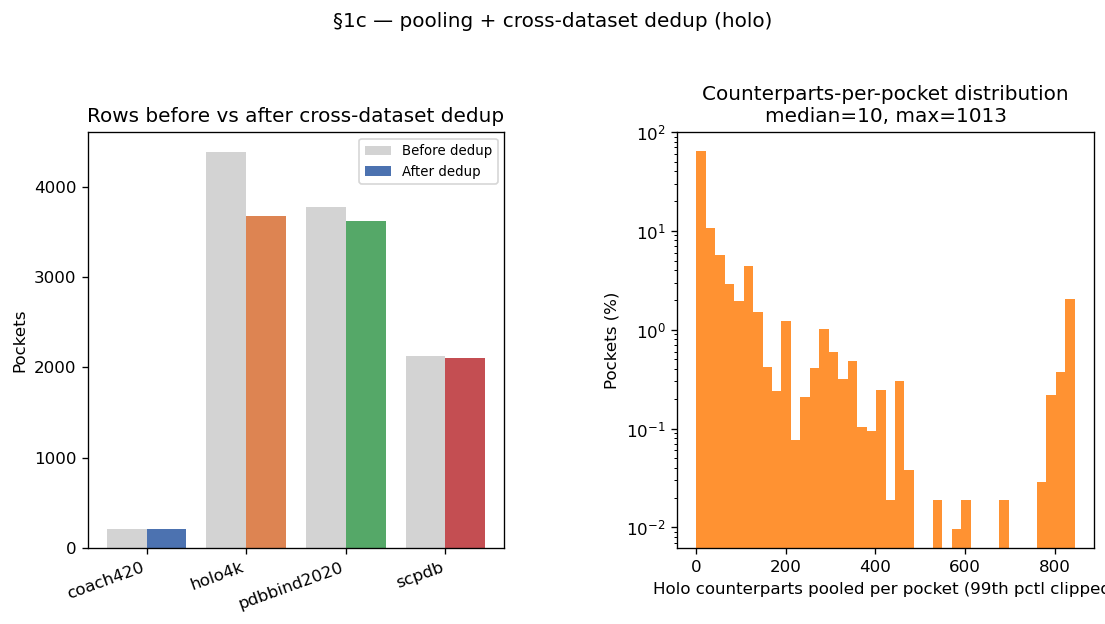

In [4]:
mol_lookup = []
for ds in DATASETS:
    mf = pd.read_csv(NL / f'mols/bound_{ds}_manifest.tsv', sep='\t',
                      usecols=['pocket', 'pdb_id', 'lig_resname'])
    mol_lookup.append(mf)
mol_lookup = pd.concat(mol_lookup, ignore_index=True).drop_duplicates('pocket').set_index('pocket')

afdb_manifest = pd.read_csv(PROJ / 'RESULTS/afdb_pockets_6A/afdb_pockets_manifest_qc.tsv', sep='\t',
                             usecols=['pocket_id', 'uniprot_acc'])
uniprot_lookup = dict(zip(afdb_manifest['pocket_id'], afdb_manifest['uniprot_acc']))

agg['pdb_id']      = agg['pocket_id'].map(mol_lookup['pdb_id'])
agg['lig_resname'] = agg['pocket_id'].map(mol_lookup['lig_resname'])
agg['uniprot_acc'] = agg['pocket_id'].map(uniprot_lookup)
print(f'uniprot_acc coverage: {agg.uniprot_acc.notna().sum():,} / {len(agg):,}')

df_raw = agg.dropna(subset=['pdb_id', 'lig_resname']).copy()
df = dedup_cross_dataset(df_raw)

dedup_diag = pd.DataFrame({
    'before_dedup': df_raw['dataset'].value_counts(),
    'after_dedup':  df['dataset'].value_counts(),
}).fillna(0).astype(int)
dedup_diag['dropped'] = dedup_diag['before_dedup'] - dedup_diag['after_dedup']
dedup_diag.loc['TOTAL'] = dedup_diag.sum()

print(f'\nPooled, PDB-deduplicated {TARGET} corpus: {len(df):,} rows '
      f'({len(df_raw) - len(df):,} cross-dataset duplicates dropped, '
      f'{(len(df_raw) - len(df)) / len(df_raw) * 100:.1f}%)')
print(dedup_diag.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
x = np.arange(len(DATASETS))
ax.bar(x - 0.2, dedup_diag.loc[DATASETS, 'before_dedup'], width=0.4,
       color='lightgrey', label='Before dedup')
ax.bar(x + 0.2, dedup_diag.loc[DATASETS, 'after_dedup'], width=0.4,
       color=[DS_COLORS[d] for d in DATASETS], label='After dedup')
ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=20, ha='right')
ax.set_ylabel('Pockets')
ax.set_title('Rows before vs after cross-dataset dedup')
ax.legend(fontsize=8)

ax = axes[1]
cnt_hist = cnt.clip(upper=cnt.quantile(0.99))
pct_hist(ax, cnt_hist, 40, color=TARGET_C, alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel(f'{TARGET.capitalize()} counterparts pooled per pocket (99th pctl clipped)')
ax.set_ylabel('Pockets (%)')
ax.set_title(f'Counterparts-per-pocket distribution\nmedian={cnt.median():.0f}, max={cnt.max()}')

fig.suptitle(f'§1c — pooling + cross-dataset dedup ({TARGET})', y=1.03)
fig.tight_layout()
square(fig);

## 1d. UniProt collisions

As in 37b: different source PDBs of the same protein share a UniProt accession. Here the collision
is softer than AFDB's — each sibling pocket draws its own independent set of AHoJ holo
counterpart PDBs rather than sharing one literal static structure — but the pools can still overlap
heavily (the same handful of holo crystal forms of a well-studied protein turning up as the
"nearest holo" for many of its sibling pockets). The **reuse fraction** below measures that
directly: for UniProt accessions with ≥2 pockets, `1 - (unique target_pdb ids used / summed
per-pocket target_pdb counts)` — 0 means every sibling drew from a disjoint set of holo
structures, 1 means they all drew from exactly the same set.

Pooled, deduplicated holo corpus: 9,620 pockets
  unique PDB entries          : 7,734
  unique UniProt accessions   : 2,972
  UniProt accessions with >1 pocket : 1,142 / 2,972 (38.4%)
  pockets sharing UniProt w/ ≥1 other pocket : 7,790 / 9,620 (81.0%)

Conformer-pool reuse fraction, UniProt accessions with ≥2 pockets (n=1,142 accessions):
count    1142.000
mean        0.587
std         0.256
min         0.000
25%         0.429
50%         0.625
75%         0.797
90%         0.888
max         0.995


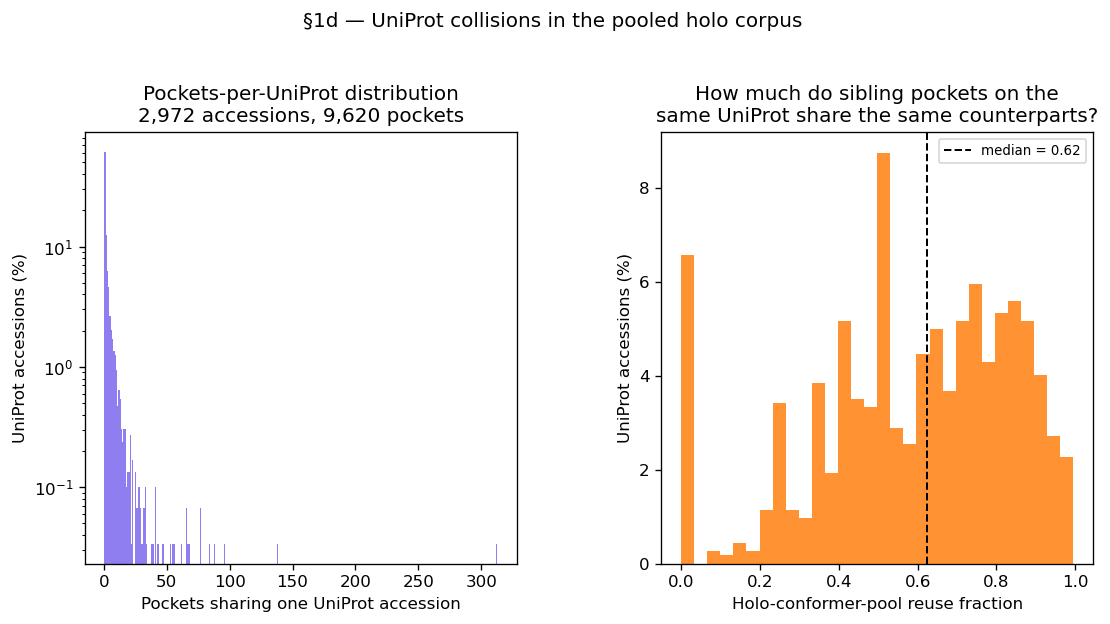

In [5]:
n_pdb  = df['pdb_id'].str.lower().nunique()
n_unip = df['uniprot_acc'].nunique()
vc     = df['uniprot_acc'].value_counts()
shared = df['uniprot_acc'].map(vc) > 1

print(f'Pooled, deduplicated {TARGET} corpus: {len(df):,} pockets')
print(f'  unique PDB entries          : {n_pdb:,}')
print(f'  unique UniProt accessions   : {n_unip:,}')
print(f'  UniProt accessions with >1 pocket : {(vc > 1).sum():,} / {n_unip:,} ({(vc > 1).mean()*100:.1f}%)')
print(f'  pockets sharing UniProt w/ ≥1 other pocket : {shared.sum():,} / {len(df):,} ({shared.mean()*100:.1f}%)')

reuse_rows = []
for uni, grp in df[df['uniprot_acc'].map(vc) > 1].groupby('uniprot_acc'):
    sets = [target_sets.get(pid, set()) for pid in grp['pocket_id']]
    sets = [s for s in sets if s]
    if len(sets) < 2:
        continue
    total = sum(len(s) for s in sets)
    union = len(set().union(*sets))
    if total == 0:
        continue
    reuse_rows.append({'uniprot_acc': uni, 'n_pockets': len(sets),
                        'reuse_fraction': 1 - union / total})
reuse_df = pd.DataFrame(reuse_rows)

print(f'\nConformer-pool reuse fraction, UniProt accessions with ≥2 pockets '
      f'(n={len(reuse_df):,} accessions):')
print(reuse_df['reuse_fraction'].describe(percentiles=[.25, .5, .75, .9]).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
bins = np.arange(1, vc.max() + 2) - 0.5
pct_hist(ax, vc.values, bins, color='#7b68ee', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('Pockets sharing one UniProt accession')
ax.set_ylabel('UniProt accessions (%)')
ax.set_title(f'Pockets-per-UniProt distribution\n{n_unip:,} accessions, {len(df):,} pockets')

ax = axes[1]
pct_hist(ax, reuse_df['reuse_fraction'], 30, color=TARGET_C, alpha=0.85)
ax.axvline(reuse_df['reuse_fraction'].median(), color='black', ls='--', lw=1.2,
           label=f'median = {reuse_df["reuse_fraction"].median():.2f}')
ax.set_xlabel(f'{TARGET.capitalize()}-conformer-pool reuse fraction')
ax.set_ylabel('UniProt accessions (%)')
ax.set_title('How much do sibling pockets on the\nsame UniProt share the same counterparts?')
ax.legend(fontsize=8)

fig.suptitle(f'§1d — UniProt collisions in the pooled {TARGET} corpus', y=1.03)
fig.tight_layout()
square(fig);

## 2. RMSD distributions

Per-pocket **median** across pooled counterparts (§1b).

Pooled RMSD summary:
        ca_rmsd   bb_rmsd   sc_rmsd   aa_rmsd
count  9620.000  9620.000  9620.000  9620.000
mean      0.479     0.502     1.024     0.820
std       0.766     0.766     0.968     0.860
min       0.008     0.007     0.018     0.013
25%       0.188     0.203     0.500     0.398
50%       0.284     0.307     0.814     0.629
75%       0.502     0.544     1.245     0.968
90%       0.974     1.020     1.881     1.502
95%       1.464     1.468     2.546     2.077
max      35.734    35.895    38.609    37.194


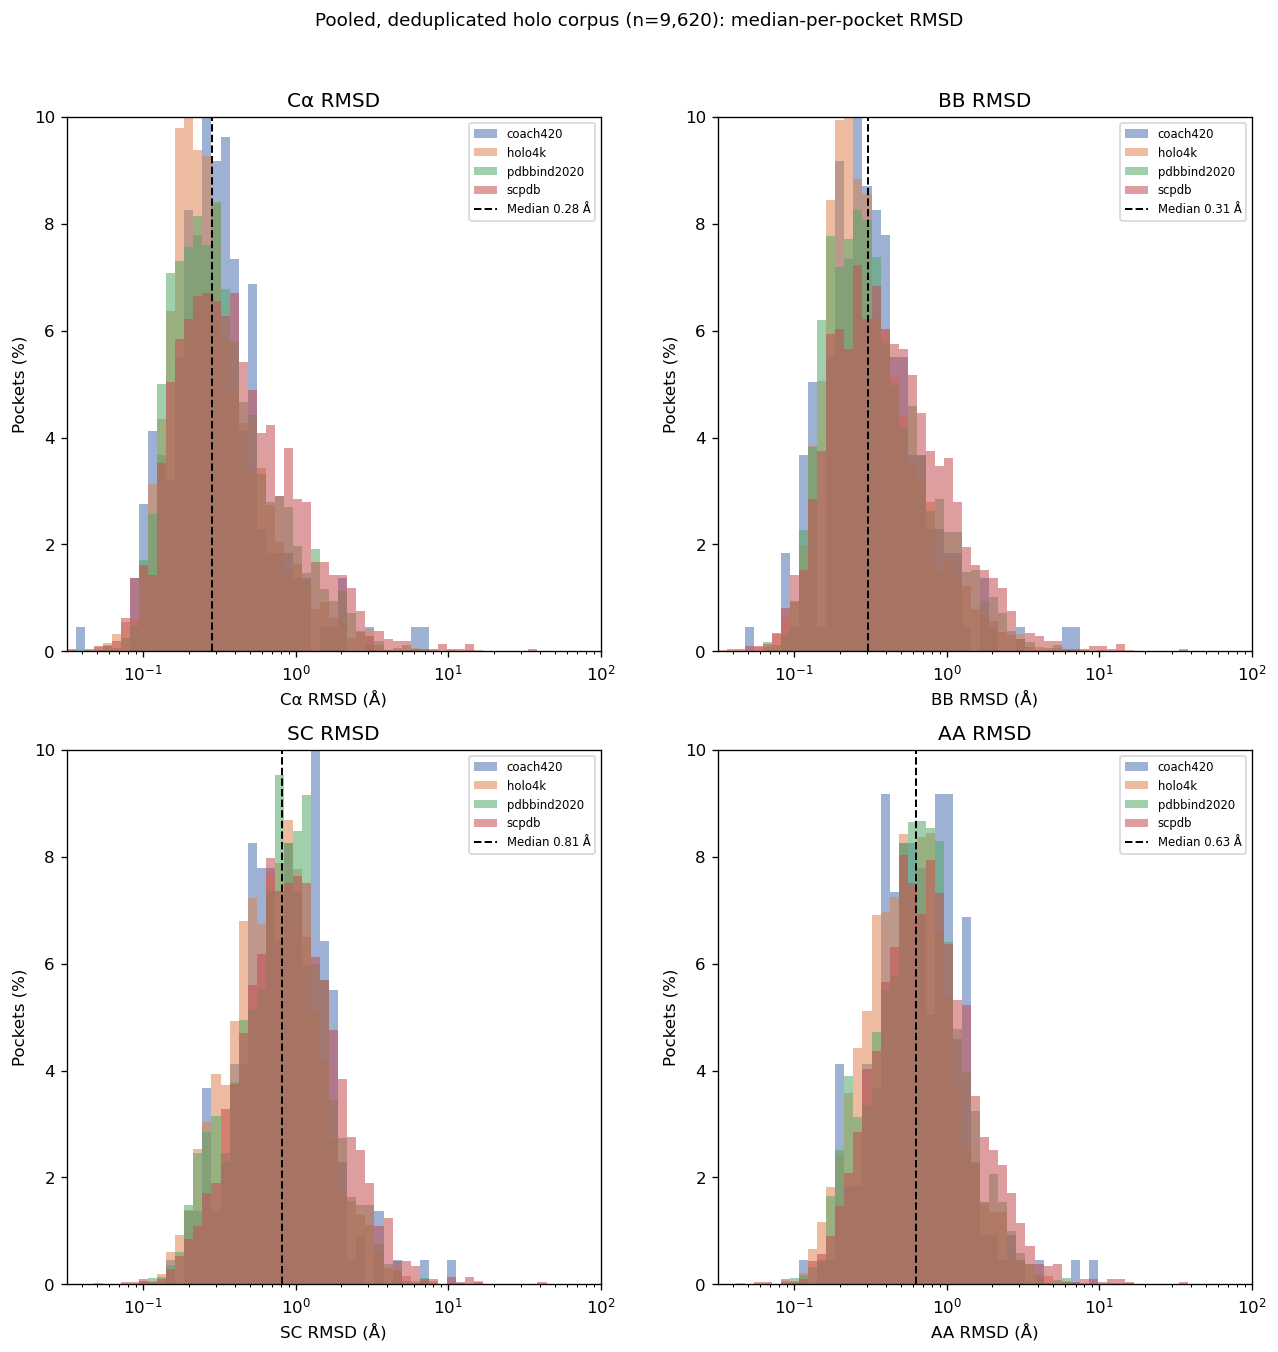

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 11))

rmsd_cols = [
    ('ca_rmsd', 'Cα RMSD (Å)'),
    ('bb_rmsd', 'BB RMSD (Å)'),
    ('sc_rmsd', 'SC RMSD (Å)'),
    ('aa_rmsd', 'AA RMSD (Å)'),
]
bins = np.logspace(-1.5, 2, 60)

for ax, (col, xlabel) in zip(axes.flat, rmsd_cols):
    for ds in DATASETS:
        vals = df[df.dataset == ds][col].dropna()
        pct_hist(ax, vals, bins, alpha=0.55, label=ds, color=DS_COLORS[ds])
    ax.set_xscale('log')
    ax.set_xlim(RMSD_LOG_LIM)
    ax.set_xticks(RMSD_LOG_TICKS)
    ax.set_ylim(RMSD_YLIM_PCT)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Pockets (%)')
    med = df[col].median()
    ax.axvline(med, color='black', ls='--', lw=1.2, label=f'Median {med:.2f} Å')
    ax.legend(fontsize=7)
    ax.set_title(xlabel.split('(')[0].strip())

fig.suptitle(f'Pooled, deduplicated {TARGET} corpus (n={len(df):,}): median-per-pocket RMSD',
             fontsize=11, y=1.02)
fig.tight_layout()
square(fig);

print('Pooled RMSD summary:')
print(df[['ca_rmsd', 'bb_rmsd', 'sc_rmsd', 'aa_rmsd']]
      .describe(percentiles=[.25, .5, .75, .9, .95]).round(3).to_string())

## 3. Score distributions: experimental vs AHoJ Holo

Δ score stats (pooled, deduplicated, mean-pooled per pocket):
count    9620.0000
mean       -0.0957
std         0.1553
min        -1.0042
5%         -0.4273
25%        -0.1348
50%        -0.0457
75%        -0.0051
95%         0.0469
max         0.3185
Name: delta_score, dtype: float64

Fraction with score drop (holo < Exp): 79.3%


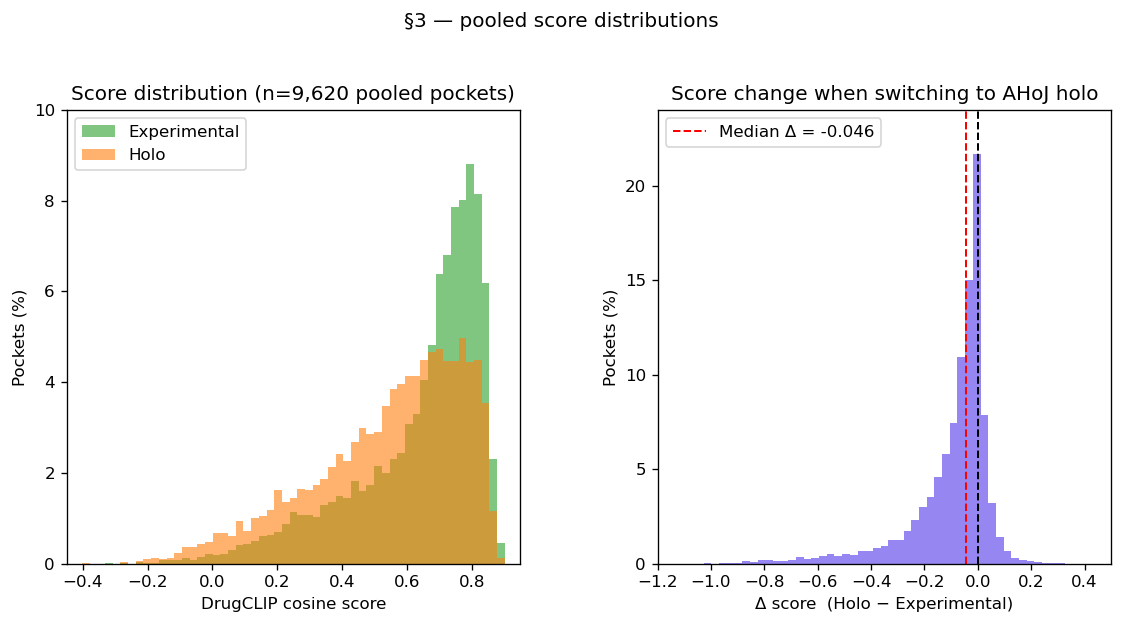

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
score_bins = np.linspace(*SCORE_LIM, 60)
pct_hist(ax, df['score_exp'], score_bins, alpha=0.6, label='Experimental', color=SOURCE_C)
pct_hist(ax, df[SCORE_COL],   score_bins, alpha=0.6, label=TARGET.capitalize(), color=TARGET_C)
ax.set_xlim(SCORE_LIM); ax.set_xticks(SCORE_TICKS); ax.set_ylim(SCORE_YLIM_PCT)
ax.set_xlabel('DrugCLIP cosine score')
ax.set_ylabel('Pockets (%)')
ax.set_title(f'Score distribution (n={len(df):,} pooled pockets)')
ax.legend()

ax = axes[1]
delta_bins = np.linspace(*DELTA_LIM, 60)
pct_hist(ax, df['delta_score'], delta_bins, color='#7b68ee', alpha=0.8)
ax.set_xlim(DELTA_LIM); ax.set_xticks(DELTA_TICKS); ax.set_ylim(DELTA_YLIM_PCT)
ax.axvline(0, color='black', ls='--', lw=1.2)
ax.axvline(df.delta_score.median(), color='red', ls='--', lw=1.2,
           label=f'Median Δ = {df.delta_score.median():.3f}')
ax.set_xlabel(f'Δ score  ({TARGET.capitalize()} − Experimental)')
ax.set_ylabel('Pockets (%)')
ax.set_title(f'Score change when switching to AHoJ {TARGET}')
ax.legend()

fig.suptitle('§3 — pooled score distributions', y=1.03)
fig.tight_layout()
square(fig);

print(f'Δ score stats (pooled, deduplicated, mean-pooled per pocket):')
print(df['delta_score'].describe(percentiles=[.05, .25, .5, .75, .95]).round(4))
pct_drop = (df.delta_score < 0).mean() * 100
print(f'\nFraction with score drop ({TARGET} < Exp): {pct_drop:.1f}%')

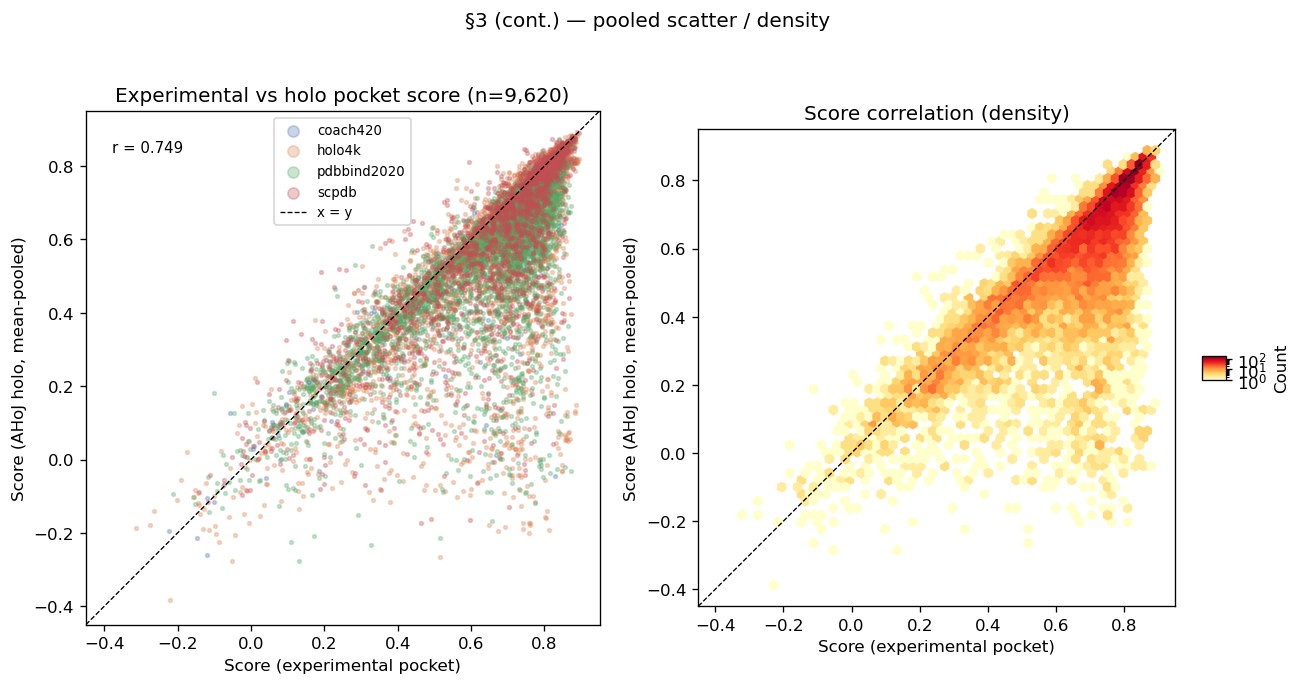

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ax = axes[0]
for ds in DATASETS:
    sub = df[df.dataset == ds]
    ax.scatter(sub.score_exp, sub[SCORE_COL], s=5, alpha=0.3,
               label=ds, color=DS_COLORS[ds], rasterized=True)
ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
ax.set_xlabel('Score (experimental pocket)')
ax.set_ylabel(f'Score (AHoJ {TARGET}, mean-pooled)')
ax.set_title(f'Experimental vs {TARGET} pocket score (n={len(df):,})')
ax.legend(markerscale=3, fontsize=8)
r, p = stats.pearsonr(df.score_exp, df[SCORE_COL])
ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes, fontsize=9)

ax = axes[1]
hb = ax.hexbin(df.score_exp, df[SCORE_COL], gridsize=60, extent=(*SCORE_LIM, *SCORE_LIM),
               cmap='YlOrRd', mincnt=1, norm=LogNorm())
ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8)
ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
plt.colorbar(hb, ax=ax, label='Count', fraction=0.046)
ax.set_xlabel('Score (experimental pocket)')
ax.set_ylabel(f'Score (AHoJ {TARGET}, mean-pooled)')
ax.set_title('Score correlation (density)')

fig.suptitle('§3 (cont.) — pooled scatter / density', y=1.03)
fig.tight_layout()
square(fig);

## 4. Δscore vs RMSD

Spearman r  (delta_score vs RMSD)  n=9,620
  ca_rmsd     r=-0.3676  p= 1.14e-305
  bb_rmsd     r=-0.3597  p= 9.84e-292
  sc_rmsd     r=-0.3858  p=  0.00e+00
  aa_rmsd     r=-0.3946  p=  0.00e+00


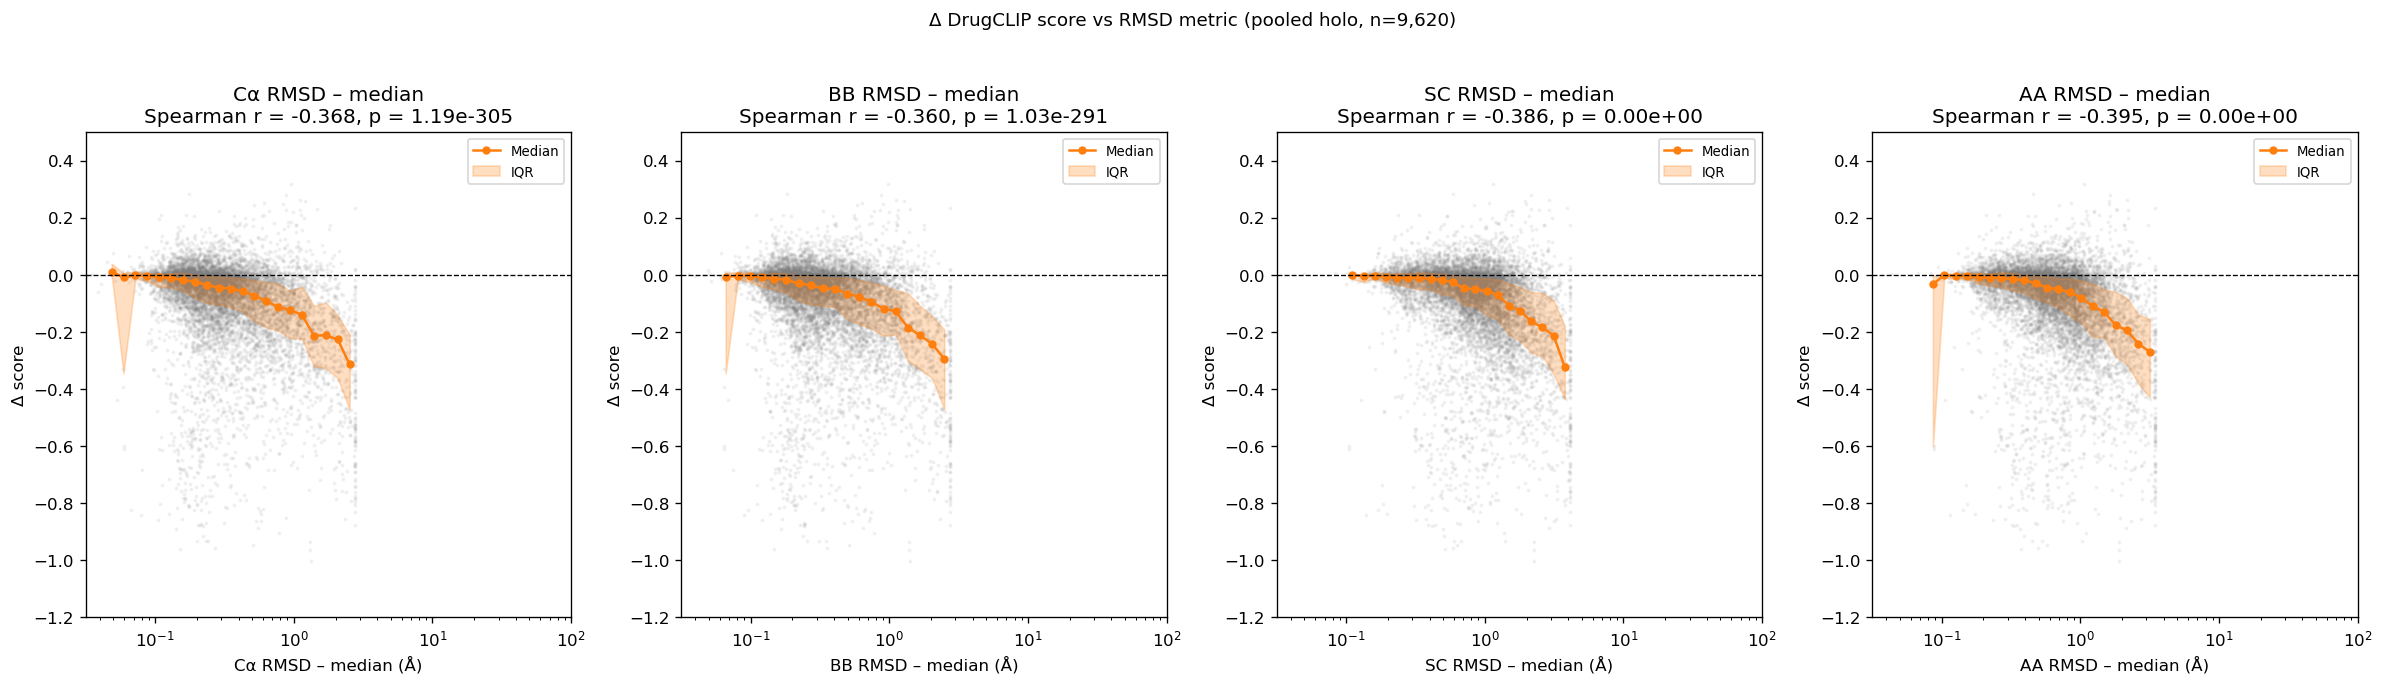

In [9]:
def plot_delta_vs_rmsd(ax, data, rmsd_col, xlabel, log_x=True):
    rmsd_vals = data[rmsd_col].clip(upper=data[rmsd_col].quantile(0.99))
    if log_x:
        bins = np.logspace(np.log10(rmsd_vals.min() + 1e-3), np.log10(rmsd_vals.max()), 30)
    else:
        bins = np.linspace(rmsd_vals.min(), rmsd_vals.max(), 30)

    bin_idx = np.digitize(rmsd_vals, bins)
    bin_mids, medians, q25s, q75s = [], [], [], []
    for b in range(1, len(bins)):
        mask = bin_idx == b
        if mask.sum() < 5:
            continue
        sub = data.loc[mask, 'delta_score']
        bin_mids.append((bins[b-1] + bins[b]) / 2)
        medians.append(sub.median()); q25s.append(sub.quantile(0.25)); q75s.append(sub.quantile(0.75))

    bin_mids = np.array(bin_mids); medians = np.array(medians)
    q25s = np.array(q25s); q75s = np.array(q75s)

    ax.scatter(rmsd_vals, data['delta_score'], s=2, alpha=0.08, color='grey', rasterized=True)
    ax.plot(bin_mids, medians, 'o-', color=TARGET_C, lw=1.5, ms=4, label='Median')
    ax.fill_between(bin_mids, q25s, q75s, alpha=0.25, color=TARGET_C, label='IQR')
    ax.axhline(0, color='black', ls='--', lw=0.8)
    if log_x:
        ax.set_xscale('log')
        ax.set_xlim(RMSD_LOG_LIM)
        ax.set_xticks(RMSD_LOG_TICKS)
    ax.set_ylim(DELTA_LIM)
    ax.set_yticks(DELTA_TICKS)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Δ score')
    ax.legend(fontsize=8)

    r, p = stats.spearmanr(rmsd_vals, data['delta_score'])
    ax.set_title(f'{xlabel.split(" (")[0]}\nSpearman r = {r:.3f}, p = {p:.2e}')


dfa = df.dropna(subset=['sc_rmsd'])
print('Spearman r  (delta_score vs RMSD)  n={:,}'.format(len(dfa)))
for col in ['ca_rmsd', 'bb_rmsd', 'sc_rmsd', 'aa_rmsd']:
    r, p = stats.spearmanr(dfa[col], dfa['delta_score'])
    print(f'  {col:<10}  r={r:>7.4f}  p={p:>10.2e}')

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, col, xlabel in [
    (axes[0], 'ca_rmsd', 'Cα RMSD – median (Å)'),
    (axes[1], 'bb_rmsd', 'BB RMSD – median (Å)'),
    (axes[2], 'sc_rmsd', 'SC RMSD – median (Å)'),
    (axes[3], 'aa_rmsd', 'AA RMSD – median (Å)'),
]:
    plot_delta_vs_rmsd(ax, dfa, col, xlabel)

fig.suptitle(f'Δ DrugCLIP score vs RMSD metric (pooled {TARGET}, n={len(dfa):,})', fontsize=11, y=1.03)
fig.tight_layout()
square(fig);

## 4b. Score correlation by SC RMSD bin

Bins on **SC RMSD (median across pooled counterparts)**. Carries through to §5 and §6.

Pearson r (exp vs holo score) by SC RMSD bin (pooled, deduplicated):
                n  n_unique_uniprot  pearson_r   p_value  median_score_exp  median_score_holo  median_delta  pct_drop
sc_rmsd_bin                                                                                                          
<1           6013              1971     0.8072  0.00e+00            0.7004             0.6222       -0.0266      75.0
1–2          2781              1149     0.7551  0.00e+00            0.7157             0.5800       -0.0834      85.2
2–5           772               444     0.5634  7.33e-66            0.7149             0.4471       -0.1975      90.0
>5             54                47     0.2087  1.30e-01            0.6829             0.1450       -0.4991     100.0


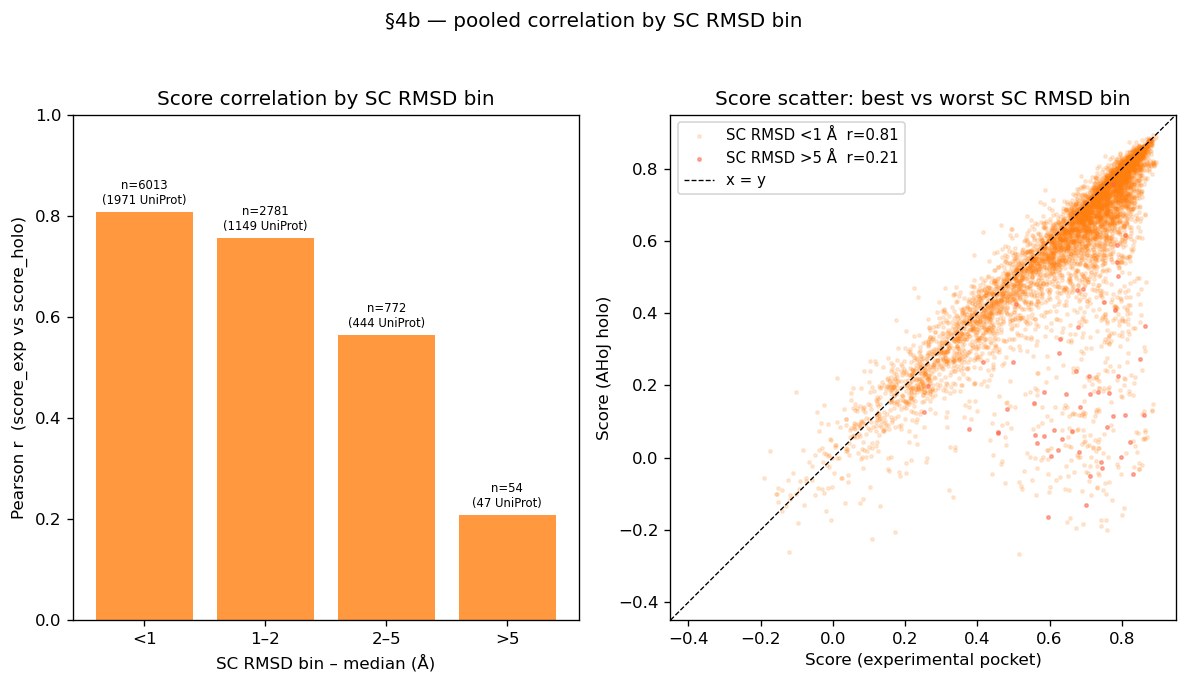

In [10]:
bin_edges  = [0, 1.0, 2.0, 5.0, np.inf]
bin_labels = ['<1', '1–2', '2–5', '>5']

dfa = df.dropna(subset=['sc_rmsd']).copy()
dfa['rmsd_bin'] = pd.cut(dfa['sc_rmsd'], bins=bin_edges, labels=bin_labels, right=False)
df['rmsd_bin'] = pd.cut(df['sc_rmsd'], bins=bin_edges, labels=bin_labels, right=False)

corr_rows = []
for b in bin_labels:
    sub = dfa[dfa.rmsd_bin == b]
    if len(sub) < 10:
        continue
    r, p = stats.pearsonr(sub.score_exp, sub[SCORE_COL])
    corr_rows.append({
        'sc_rmsd_bin': b, 'n': len(sub), 'n_unique_uniprot': sub['uniprot_acc'].nunique(),
        'pearson_r': round(r, 4), 'p_value': f'{p:.2e}',
        'median_score_exp': round(sub.score_exp.median(), 4),
        f'median_{SCORE_COL}': round(sub[SCORE_COL].median(), 4),
        'median_delta': round(sub.delta_score.median(), 4),
        'pct_drop': round((sub.delta_score < 0).mean() * 100, 1),
    })
corr_tbl = pd.DataFrame(corr_rows).set_index('sc_rmsd_bin')
print(f'Pearson r (exp vs {TARGET} score) by SC RMSD bin (pooled, deduplicated):')
print(corr_tbl.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))

ax = axes[0]
x = np.arange(len(corr_tbl))
bars = ax.bar(x, corr_tbl['pearson_r'], color=TARGET_C, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(corr_tbl.index)
ax.set_xlabel('SC RMSD bin – median (Å)')
ax.set_ylabel(f'Pearson r  (score_exp vs {SCORE_COL})')
ax.set_title('Score correlation by SC RMSD bin')
ax.set_ylim(0, 1.0)
for bar, (_, row) in zip(bars, corr_tbl.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={int(row["n"])}\n({int(row["n_unique_uniprot"])} UniProt)',
            ha='center', va='bottom', fontsize=7)

ax = axes[1]
for b, color, alpha in [('<1', TARGET_C, 0.15), ('>5', 'tomato', 0.5)]:
    sub = dfa[dfa.rmsd_bin == b]
    if len(sub) < 5:
        continue
    r, _ = stats.pearsonr(sub.score_exp, sub[SCORE_COL])
    ax.scatter(sub.score_exp, sub[SCORE_COL], s=4, alpha=alpha, color=color,
               label=f'SC RMSD {b} Å  r={r:.2f}', rasterized=True)
ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
ax.set_xlabel('Score (experimental pocket)')
ax.set_ylabel(f'Score (AHoJ {TARGET})')
ax.set_title('Score scatter: best vs worst SC RMSD bin')
ax.legend(fontsize=9)

fig.suptitle('§4b — pooled correlation by SC RMSD bin', y=1.03)
fig.tight_layout()
square(fig);

## 5. RMSD bins — score drop at low / medium / high RMSD

Δ score by SC RMSD bin (pooled, deduplicated):
             n  median     q25     q75  pct_drop
rmsd_bin                                        
<1        6013 -0.0266 -0.0813 -0.0000   75.0208
1–2       2781 -0.0834 -0.1808 -0.0205   85.2211
2–5        772 -0.1975 -0.3253 -0.0820   90.0259
>5          54 -0.4991 -0.6007 -0.3044  100.0000


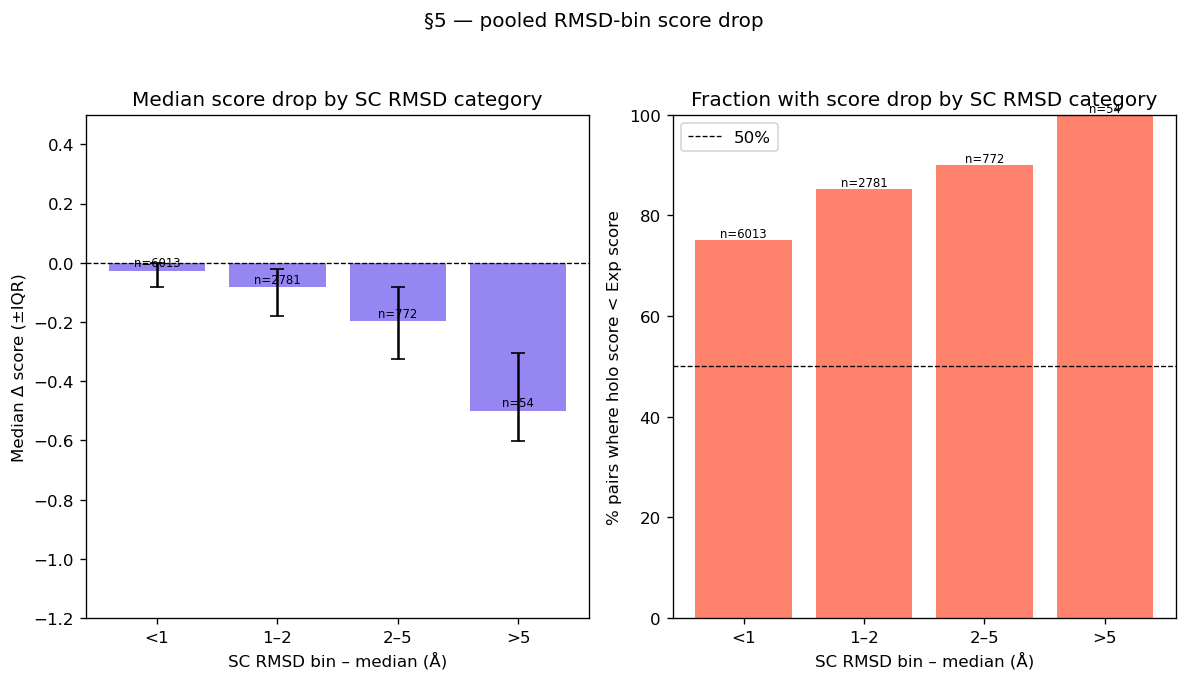

In [11]:
summary = (
    df.groupby('rmsd_bin', observed=True)['delta_score']
    .agg(n='count', median='median',
         q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75),
         pct_drop=lambda x: (x < 0).mean() * 100)
    .round(4)
)
print('Δ score by SC RMSD bin (pooled, deduplicated):')
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))

ax = axes[0]
bins_present = summary.index.tolist()
x = np.arange(len(bins_present))
ax.bar(x, summary['median'], yerr=[summary['median'] - summary['q25'], summary['q75'] - summary['median']],
       capsize=4, color='#7b68ee', alpha=0.8)
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(bins_present)
ax.set_ylim(DELTA_LIM); ax.set_yticks(DELTA_TICKS)
ax.set_xlabel('SC RMSD bin – median (Å)')
ax.set_ylabel('Median Δ score (±IQR)')
ax.set_title('Median score drop by SC RMSD category')

ax = axes[1]
ax.bar(x, summary['pct_drop'], color='tomato', alpha=0.8)
ax.axhline(50, color='black', ls='--', lw=0.8, label='50%')
ax.set_xticks(x); ax.set_xticklabels(bins_present)
ax.set_ylim(0, 100)
ax.set_xlabel('SC RMSD bin – median (Å)')
ax.set_ylabel(f'% pairs where {TARGET} score < Exp score')
ax.set_title('Fraction with score drop by SC RMSD category')
ax.legend()

for ax_i, col in [(axes[0], 'median'), (axes[1], 'pct_drop')]:
    for xi, (_, row) in zip(x, summary.iterrows()):
        ax_i.text(xi, row[col] + 0.005, f'n={int(row["n"])}', ha='center', va='bottom', fontsize=7)

fig.suptitle('§5 — pooled RMSD-bin score drop', y=1.03)
fig.tight_layout()
square(fig);

## 6. Absolute score comparison stratified by RMSD

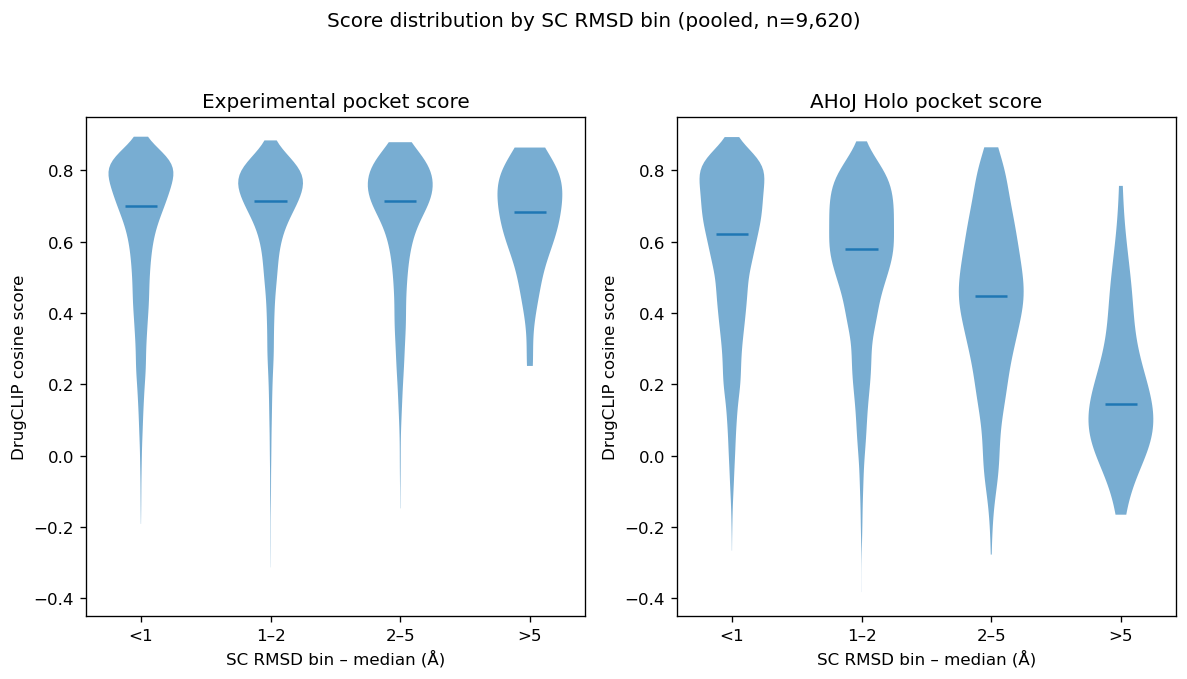

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
for ax, score_col, title in [
    (axes[0], 'score_exp', 'Experimental pocket score'),
    (axes[1], SCORE_COL,   f'AHoJ {TARGET.capitalize()} pocket score'),
]:
    groups = [df[df.rmsd_bin == b][score_col].dropna().values
              for b in bin_labels if b in df.rmsd_bin.cat.categories]
    labels_present = [b for b in bin_labels if b in df.rmsd_bin.cat.categories]
    vp = ax.violinplot(groups, positions=np.arange(len(groups)), showmedians=True, showextrema=False)
    for body in vp['bodies']:
        body.set_alpha(0.6)
    ax.set_xticks(np.arange(len(labels_present))); ax.set_xticklabels(labels_present)
    ax.set_ylim(SCORE_LIM); ax.set_yticks(SCORE_TICKS)
    ax.set_xlabel('SC RMSD bin – median (Å)')
    ax.set_ylabel('DrugCLIP cosine score')
    ax.set_title(title)

fig.suptitle(f'Score distribution by SC RMSD bin (pooled, n={len(df):,})', fontsize=12, y=1.03)
fig.tight_layout()
square(fig);

## 7. Counterpart-pool size as confounder

Pockets differ hugely in how many AHoJ holo counterparts fed the §1b mean-pool (see §1b for
the exact median/max). Does the pooled Δscore systematically depend on how many counterparts went
into it — e.g. because averaging over more conformers dampens extreme scores toward the source
score, mechanically shrinking |Δscore| for well-redeposited proteins?

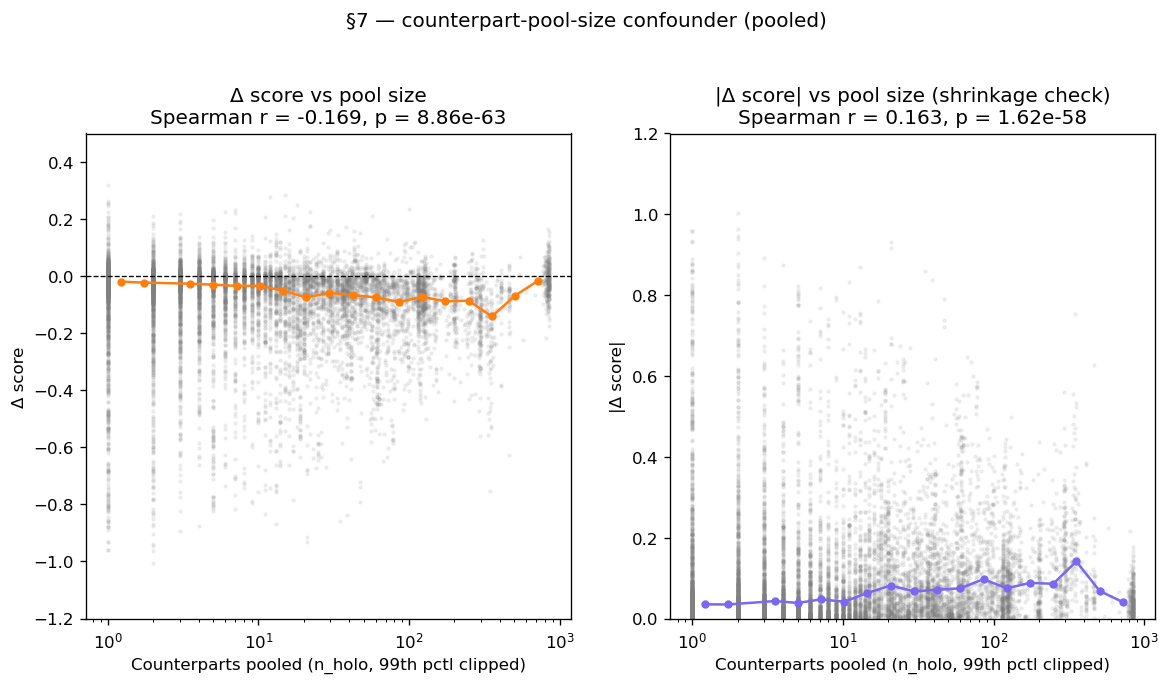

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))

ax = axes[0]
n_clip = df[N_COL].clip(upper=df[N_COL].quantile(0.99))
ax.scatter(n_clip, df['delta_score'], s=3, alpha=0.1, color='grey', rasterized=True)
bins = np.logspace(0, np.log10(n_clip.max()), 20)
bidx = np.digitize(n_clip, bins)
bm, med = [], []
for b in range(1, len(bins)):
    mask = bidx == b
    if mask.sum() < 5:
        continue
    bm.append((bins[b-1] + bins[b]) / 2)
    med.append(df.loc[mask, 'delta_score'].median())
ax.plot(bm, med, 'o-', color=TARGET_C, lw=1.5, ms=4)
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_ylim(DELTA_LIM); ax.set_yticks(DELTA_TICKS)
ax.set_xlabel(f'Counterparts pooled ({N_COL}, 99th pctl clipped)')
ax.set_ylabel('Δ score')
r, p = stats.spearmanr(df[N_COL], df['delta_score'])
ax.set_title(f'Δ score vs pool size\nSpearman r = {r:.3f}, p = {p:.2e}')

ax = axes[1]
abs_clip = df['delta_score'].abs()
ax.scatter(n_clip, abs_clip, s=3, alpha=0.1, color='grey', rasterized=True)
bm2, med2 = [], []
for b in range(1, len(bins)):
    mask = bidx == b
    if mask.sum() < 5:
        continue
    bm2.append((bins[b-1] + bins[b]) / 2)
    med2.append(abs_clip[mask].median())
ax.plot(bm2, med2, 'o-', color='#7b68ee', lw=1.5, ms=4)
ax.set_xscale('log')
ax.set_ylim(0, max(abs(v) for v in DELTA_LIM))
ax.set_xlabel(f'Counterparts pooled ({N_COL}, 99th pctl clipped)')
ax.set_ylabel('|Δ score|')
r2, p2 = stats.spearmanr(df[N_COL], abs_clip)
ax.set_title(f'|Δ score| vs pool size (shrinkage check)\nSpearman r = {r2:.3f}, p = {p2:.2e}')

fig.suptitle('§7 — counterpart-pool-size confounder (pooled)', y=1.03)
fig.tight_layout()
square(fig);

## 8. Summary table

In [14]:
summary_tbl = df.groupby('dataset').agg(
    n_pairs          = ('delta_score', 'count'),
    n_unique_uniprot = ('uniprot_acc', 'nunique'),
    median_score_exp = ('score_exp', 'median'),
    **{f'median_{SCORE_COL}': (SCORE_COL, 'median')},
    median_delta     = ('delta_score', 'median'),
    pct_drop         = ('delta_score', lambda x: (x < 0).mean() * 100),
    med_ca_rmsd      = ('ca_rmsd', 'median'),
    med_bb_rmsd      = ('bb_rmsd', 'median'),
    med_sc_rmsd      = ('sc_rmsd', 'median'),
    med_aa_rmsd      = ('aa_rmsd', 'median'),
    median_n_pooled  = (N_COL, 'median'),
).round(4)
summary_tbl.loc['POOLED (all)'] = {
    'n_pairs':               len(df),
    'n_unique_uniprot':      df['uniprot_acc'].nunique(),
    'median_score_exp':      round(df.score_exp.median(), 4),
    f'median_{SCORE_COL}':   round(df[SCORE_COL].median(), 4),
    'median_delta':          round(df.delta_score.median(), 4),
    'pct_drop':              round((df.delta_score < 0).mean() * 100, 4),
    'med_ca_rmsd':           round(df.ca_rmsd.median(), 4),
    'med_bb_rmsd':           round(df.bb_rmsd.median(), 4),
    'med_sc_rmsd':           round(df.sc_rmsd.median(), 4),
    'med_aa_rmsd':           round(df.aa_rmsd.median(), 4),
    'median_n_pooled':       round(df[N_COL].median(), 4),
}
print('Summary (post-dedup per-dataset rows + pooled headline):')
print(summary_tbl.to_string())
summary_tbl

Summary (post-dedup per-dataset rows + pooled headline):
              n_pairs  n_unique_uniprot  median_score_exp  median_score_holo  median_delta  pct_drop  med_ca_rmsd  med_bb_rmsd  med_sc_rmsd  med_aa_rmsd  median_n_pooled
dataset                                                                                                                                                                  
coach420          218               153            0.6743             0.5546       -0.0354   74.7706       0.2867       0.3029       0.8478       0.6374              6.0
holo4k           3679               673            0.7122             0.6031       -0.0360   76.0805       0.2566       0.2773       0.7336       0.5661              7.0
pdbbind2020      3618               919            0.7037             0.5673       -0.0647   86.2908       0.2924       0.3083       0.8394       0.6537             36.0
scpdb            2105              2026            0.7106             0.6280       -0.0286   

,n_pairs,n_unique_uniprot,median_score_exp,median_score_holo,median_delta,pct_drop,med_ca_rmsd,med_bb_rmsd,med_sc_rmsd,med_aa_rmsd,median_n_pooled
dataset,,,,,,,,,,,
coach420,218,153,0.6743,0.5546,-0.0354,74.7706,0.2867,0.3029,0.8478,0.6374,6.0
holo4k,3679,673,0.7122,0.6031,-0.0360,76.0805,0.2566,0.2773,0.7336,0.5661,7.0
pdbbind2020,3618,919,0.7037,0.5673,-0.0647,86.2908,0.2924,0.3083,0.8394,0.6537,36.0
scpdb,2105,2026,0.7106,0.6280,-0.0286,73.4442,0.3493,0.3822,0.9103,0.7118,3.0
POOLED (all),9620,2972,0.7077,0.5931,-0.0457,79.3139,0.2839,0.3066,0.8136,0.6290,10.0


In [15]:
out_path = OUT_DIR / f'ahoj_{TARGET}_vs_exp_scores_pooled_dedup.tsv'
df.to_csv(out_path, sep='\t', index=False)
print(f'Saved: {out_path}  ({len(df):,} rows)')
print(f'Columns: {list(df.columns)}')

Saved: /Users/jsutges/Documents/CHEMBL_DRUGCLIP/RESULTS/ahoj_pooled/ahoj_holo_vs_exp_scores_pooled_dedup.tsv  (9,620 rows)
Columns: ['pocket_id', 'dataset', 'score_exp', 'score_holo', 'pocket_pocket_score', 'ca_rmsd', 'bb_rmsd', 'sc_rmsd', 'aa_rmsd', 'n_holo', 'delta_score', 'pdb_id', 'lig_resname', 'uniprot_acc', 'rmsd_bin']


## 9. Pocket–pocket embedding cosine similarity

Same mean-pooling as §1b: mean per-fold cosine similarity between the experimental pocket rep and
each QC-passing holo counterpart's pocket rep, averaged across counterparts.

Updated: /Users/jsutges/Documents/CHEMBL_DRUGCLIP/RESULTS/ahoj_pooled/ahoj_holo_vs_exp_scores_pooled_dedup.tsv  (final)


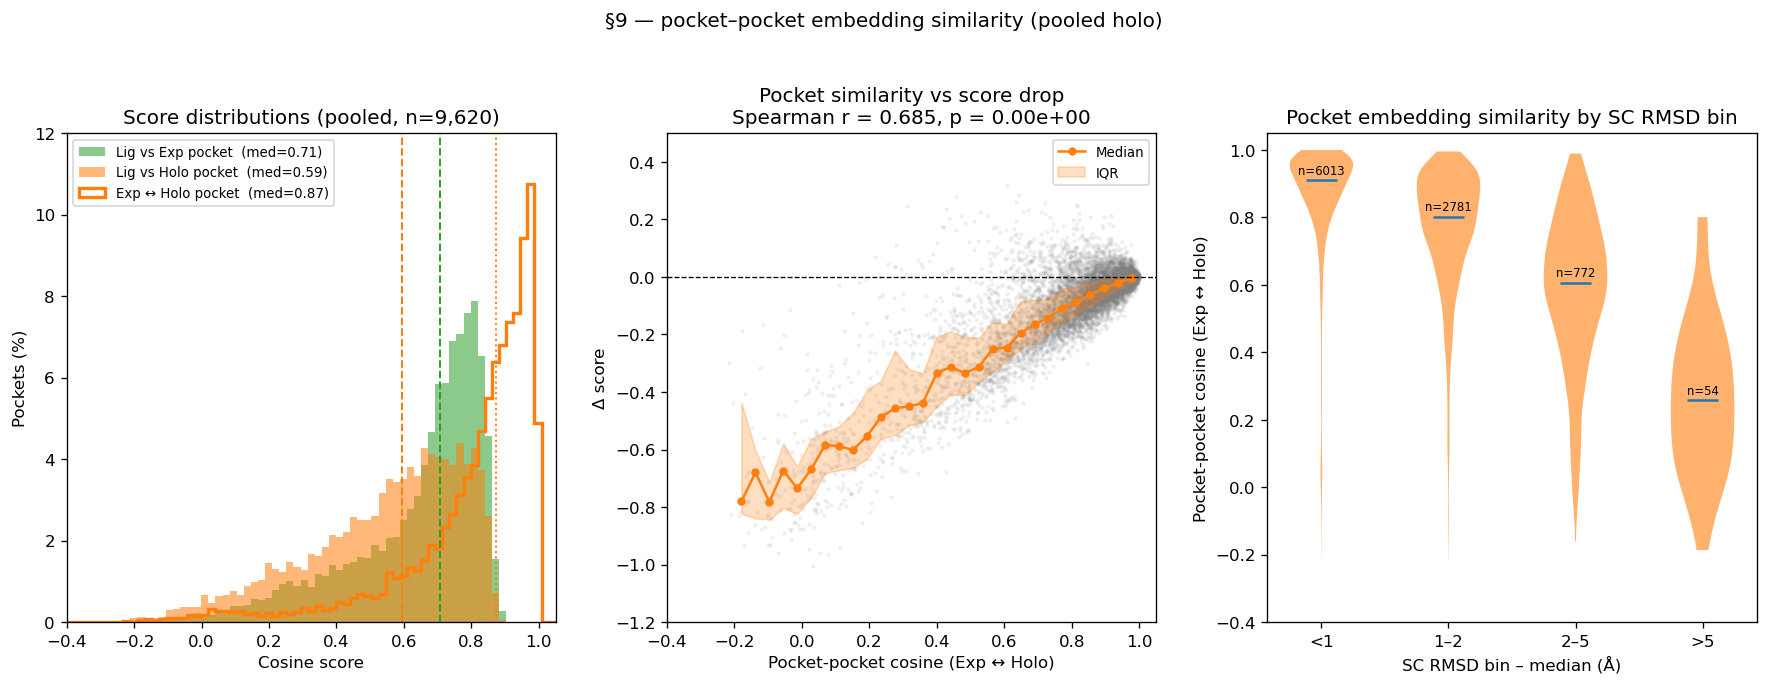

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
score_bins = np.linspace(*PP_LIM, 70)

ax = axes[0]
for scores, color, label in [
    (df['score_exp'], SOURCE_C, 'Lig vs Exp pocket'),
    (df[SCORE_COL],   TARGET_C, f'Lig vs {TARGET.capitalize()} pocket'),
]:
    pct_hist(ax, scores.dropna(), score_bins, alpha=0.55, color=color,
             label=f'{label}  (med={scores.median():.2f})')
# Pocket-pocket similarity stays in the same (target) colour family as the rest
# of the notebook — drawn as an outline instead of filled bars so it's still
# visually distinct from the filled "Lig vs {TARGET}" series above.
pct_hist(ax, df['pocket_pocket_score'].dropna(), score_bins, histtype='step',
         color=TARGET_C, linewidth=2,
         label=f"Exp ↔ {TARGET.capitalize()} pocket  (med={df['pocket_pocket_score'].median():.2f})")
ax.set_xlim(PP_LIM); ax.set_ylim(PP_YLIM_PCT)
ax.set_xlabel('Cosine score')
ax.set_ylabel('Pockets (%)')
ax.set_title(f'Score distributions (pooled, n={len(df):,})')
ax.legend(fontsize=8)
for scores, color, ls in [(df['score_exp'], SOURCE_C, '--'), (df[SCORE_COL], TARGET_C, '--'),
                           (df['pocket_pocket_score'], TARGET_C, ':')]:
    ax.axvline(scores.median(), color=color, ls=ls, lw=1.2)

ax = axes[1]
valid = df.dropna(subset=['pocket_pocket_score'])
ax.scatter(valid['pocket_pocket_score'], valid['delta_score'], s=3, alpha=0.08, color='grey', rasterized=True)
pps_clip = valid['pocket_pocket_score'].clip(lower=-0.2, upper=1.0)
bins2 = np.linspace(pps_clip.min(), pps_clip.max(), 30)
bidx = np.digitize(pps_clip, bins2)
bm, med, q25, q75 = [], [], [], []
for b in range(1, len(bins2)):
    mask = bidx == b
    if mask.sum() < 5:
        continue
    sub = valid.loc[mask, 'delta_score']
    bm.append((bins2[b-1] + bins2[b]) / 2)
    med.append(sub.median()); q25.append(sub.quantile(0.25)); q75.append(sub.quantile(0.75))
bm, med, q25, q75 = map(np.array, (bm, med, q25, q75))
ax.plot(bm, med, 'o-', color=TARGET_C, lw=1.5, ms=4, label='Median')
ax.fill_between(bm, q25, q75, alpha=0.25, color=TARGET_C, label='IQR')
ax.axhline(0, color='k', ls='--', lw=0.8)
r, p = stats.spearmanr(valid['pocket_pocket_score'], valid['delta_score'])
ax.set_xlim(PP_LIM); ax.set_ylim(DELTA_LIM); ax.set_yticks(DELTA_TICKS)
ax.set_xlabel(f'Pocket-pocket cosine (Exp ↔ {TARGET.capitalize()})')
ax.set_ylabel('Δ score')
ax.set_title(f'Pocket similarity vs score drop\nSpearman r = {r:.3f}, p = {p:.2e}')
ax.legend(fontsize=8)

ax = axes[2]
bins_present = [b for b in bin_labels if b in df['rmsd_bin'].cat.categories]
groups = [df[df['rmsd_bin'] == b]['pocket_pocket_score'].dropna().values for b in bins_present]
vp = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, showextrema=False)
for body in vp['bodies']:
    body.set_facecolor(TARGET_C); body.set_alpha(0.6)
ax.set_xticks(range(len(bins_present))); ax.set_xticklabels(bins_present)
ax.set_ylim(PP_LIM)
ax.set_xlabel('SC RMSD bin – median (Å)')
ax.set_ylabel(f'Pocket-pocket cosine (Exp ↔ {TARGET.capitalize()})')
ax.set_title('Pocket embedding similarity by SC RMSD bin')
for i, g in enumerate(groups):
    ax.text(i, np.median(g) + 0.01, f'n={len(g)}', ha='center', va='bottom', fontsize=7)

fig.suptitle(f'§9 — pocket–pocket embedding similarity (pooled {TARGET})', fontsize=12, y=1.03)
fig.tight_layout()
square(fig);

out_path = OUT_DIR / f'ahoj_{TARGET}_vs_exp_scores_pooled_dedup.tsv'
df.to_csv(out_path, sep='\t', index=False)
print(f'Updated: {out_path}  (final)')

Spearman r  (pocket_pocket_score vs RMSD)  n=9,620
  metric            r           p
  ca_rmsd     -0.4822    0.00e+00
  bb_rmsd     -0.4751    0.00e+00
  sc_rmsd     -0.5187    0.00e+00
  aa_rmsd     -0.5319    0.00e+00


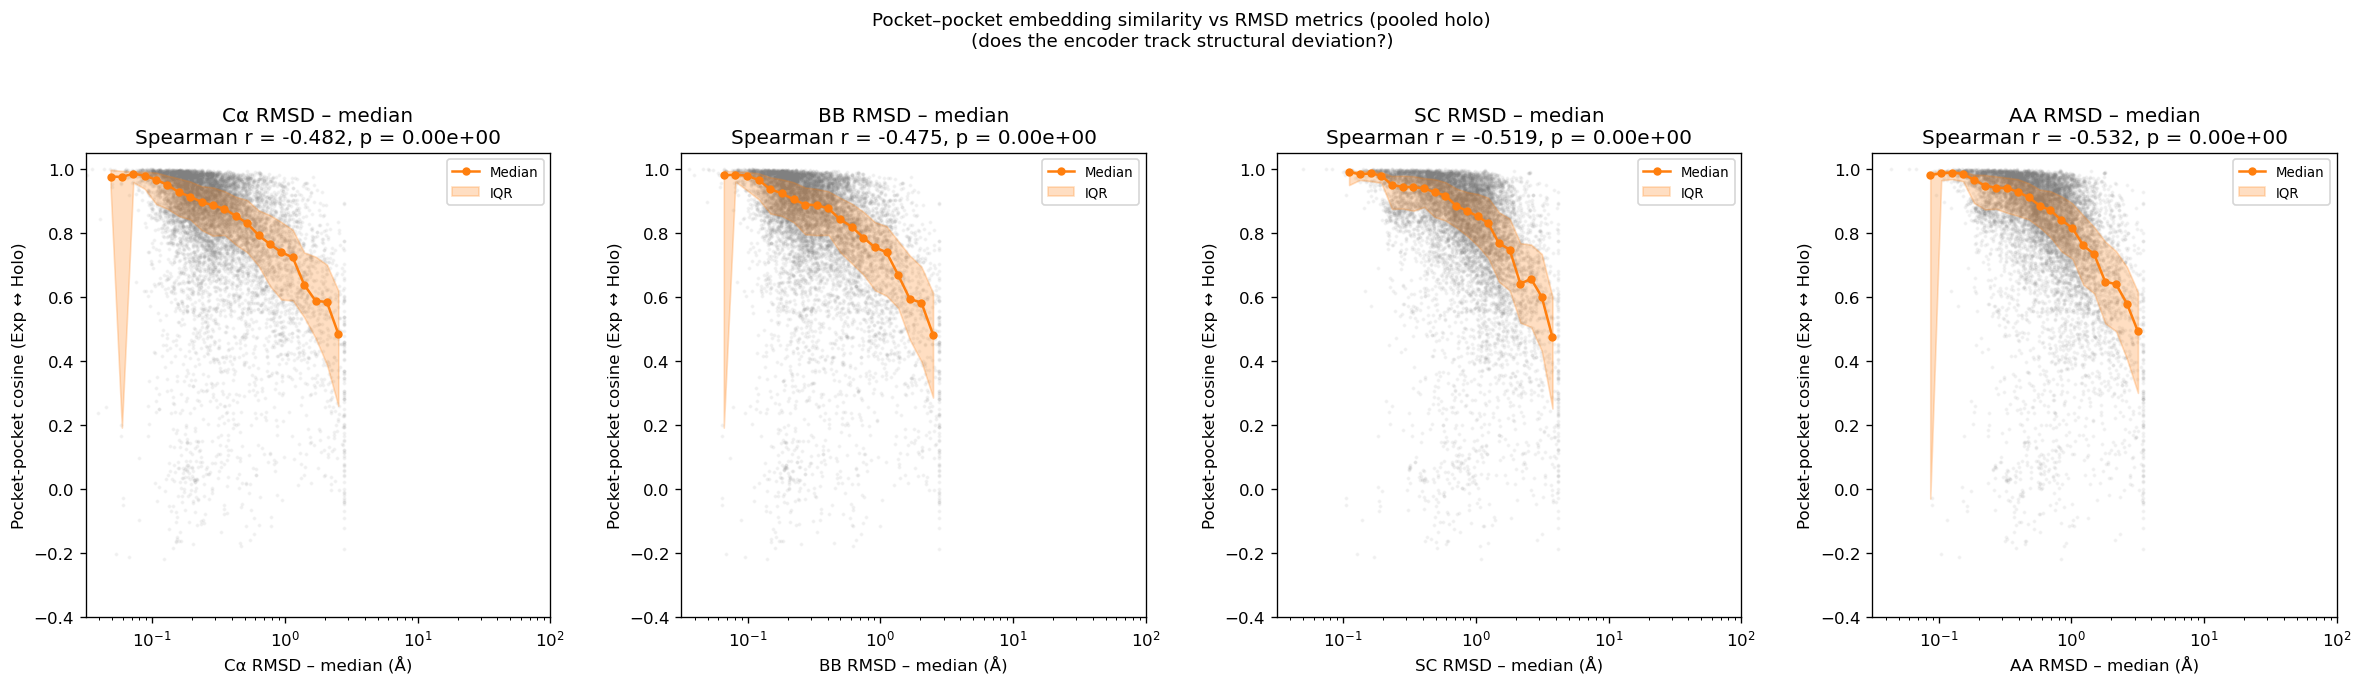

In [17]:
# Pocket-pocket cosine (Y) vs RMSD (X) — does the encoder track structural deviation?
valid_pp = df.dropna(subset=['pocket_pocket_score', 'sc_rmsd'])

rmsd_metrics = [
    ('ca_rmsd', 'Cα RMSD – median (Å)'),
    ('bb_rmsd', 'BB RMSD – median (Å)'),
    ('sc_rmsd', 'SC RMSD – median (Å)'),
    ('aa_rmsd', 'AA RMSD – median (Å)'),
]

print(f'Spearman r  (pocket_pocket_score vs RMSD)  n={len(valid_pp):,}')
print(f'  {"metric":<10}  {"r":>7}  {"p":>10}')
for col, label in rmsd_metrics:
    sub = valid_pp.dropna(subset=[col])
    r, p = stats.spearmanr(sub[col], sub['pocket_pocket_score'])
    print(f'  {col:<10}  {r:>7.4f}  {p:>10.2e}')

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))

for ax, (col, xlabel) in zip(axes, rmsd_metrics):
    sub = valid_pp.dropna(subset=[col]).copy()
    vals = sub[col].clip(upper=sub[col].quantile(0.99))

    bins = np.logspace(np.log10(vals.min() + 1e-3), np.log10(vals.max()), 30)
    bidx = np.digitize(vals, bins)
    bm, med, q25, q75 = [], [], [], []
    for b in range(1, len(bins)):
        mask = bidx == b
        if mask.sum() < 5:
            continue
        s = sub.loc[mask, 'pocket_pocket_score']
        bm.append((bins[b-1] + bins[b]) / 2)
        med.append(s.median()); q25.append(s.quantile(0.25)); q75.append(s.quantile(0.75))
    bm, med, q25, q75 = map(np.array, (bm, med, q25, q75))

    ax.scatter(vals, sub['pocket_pocket_score'],
               s=2, alpha=0.07, color='grey', rasterized=True)
    ax.plot(bm, med, 'o-', color=TARGET_C, lw=1.5, ms=4, label='Median')
    ax.fill_between(bm, q25, q75, alpha=0.25, color=TARGET_C, label='IQR')
    ax.set_xscale('log')
    ax.set_xlim(RMSD_LOG_LIM); ax.set_xticks(RMSD_LOG_TICKS)
    ax.set_ylim(PP_LIM)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f'Pocket-pocket cosine (Exp ↔ {TARGET.capitalize()})')
    r, p = stats.spearmanr(sub[col], sub['pocket_pocket_score'])
    ax.set_title(f'{xlabel.split(" (")[0]}\nSpearman r = {r:.3f}, p = {p:.2e}')
    ax.legend(fontsize=8)

fig.suptitle(f'Pocket–pocket embedding similarity vs RMSD metrics (pooled {TARGET})\n'
             '(does the encoder track structural deviation?)',
             fontsize=11, y=1.03)
fig.tight_layout()
square(fig);

## 10. UniProt-deduped sensitivity check

§1d showed source pockets on the same protein are common. As in 37b, this collapses to **one row per
UniProt accession** (the pocket with the median `sc_rmsd` among its siblings) and recomputes the
headline numbers, to check whether the pooled correlations are being driven by a few
heavily-redeposited UniProt accessions.

In [18]:
def pick_median_sc_rmsd(g: pd.DataFrame) -> pd.Series:
    sub = g.dropna(subset=['sc_rmsd'])
    if sub.empty:
        return g.iloc[0]
    target = sub['sc_rmsd'].median()
    return sub.iloc[(sub['sc_rmsd'] - target).abs().argsort().iloc[0]]

df_unip = (
    df.groupby('uniprot_acc', group_keys=False)
      .apply(pick_median_sc_rmsd, include_groups=False)
      .reset_index()
)
print(f'UniProt-deduped: {len(df_unip):,} rows (one per UniProt accession, '
      f'vs {len(df):,} pooled pockets / {df["uniprot_acc"].nunique():,} accessions)')

r_pooled, _  = stats.pearsonr(df.score_exp, df[SCORE_COL])
r_unip,   _  = stats.pearsonr(df_unip.score_exp, df_unip[SCORE_COL])
rs_pooled, _ = stats.spearmanr(df.sc_rmsd.dropna(), df.loc[df.sc_rmsd.notna(), 'delta_score'])
rs_unip,   _ = stats.spearmanr(df_unip.sc_rmsd.dropna(), df_unip.loc[df_unip.sc_rmsd.notna(), 'delta_score'])

check_tbl = pd.DataFrame({
    'pooled (n=%d)' % len(df): {
        f'pearson_r(score_exp, {SCORE_COL})': round(r_pooled, 4),
        'spearman_r(sc_rmsd, delta_score)':   round(rs_pooled, 4),
        'median_delta_score':                 round(df.delta_score.median(), 4),
        'pct_drop':                           round((df.delta_score < 0).mean() * 100, 1),
    },
    'UniProt-deduped (n=%d)' % len(df_unip): {
        f'pearson_r(score_exp, {SCORE_COL})': round(r_unip, 4),
        'spearman_r(sc_rmsd, delta_score)':   round(rs_unip, 4),
        'median_delta_score':                 round(df_unip.delta_score.median(), 4),
        'pct_drop':                           round((df_unip.delta_score < 0).mean() * 100, 1),
    },
})
print(check_tbl.to_string())
check_tbl

UniProt-deduped: 2,972 rows (one per UniProt accession, vs 9,620 pooled pockets / 2,972 accessions)
                                  pooled (n=9620)  UniProt-deduped (n=2972)
pearson_r(score_exp, score_holo)           0.7493                    0.7547
spearman_r(sc_rmsd, delta_score)          -0.3858                   -0.3942
median_delta_score                        -0.0457                   -0.0336
pct_drop                                  79.3000                   75.5000


,pooled (n=9620),UniProt-deduped (n=2972)
"pearson_r(score_exp, score_holo)",0.7493,0.7547
"spearman_r(sc_rmsd, delta_score)",-0.3858,-0.3942
median_delta_score,-0.0457,-0.0336
pct_drop,79.3000,75.5000
